In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import hypergeom, spearmanr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/dla_qwen_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

TYPES = ["attribute", "relation"]
N_LAYER, N_HEAD = 28, 28
N_COMP = N_LAYER * N_HEAD + N_LAYER + 1

MIN_GROUP = 10
MIN_BIN = 5
N_BINS = 8
N_PERM = 500
K_TOP = 20
MIN_LOGITS = 0.05

CONTRASTS = {
    "flip": ("false_yes", "true_no", 1),
    "evidence": ("false_yes", "true_yes", 1),
    "evidence_matched": ("false_yes", "true_yes", N_BINS),
}
UNITS = {
    "attribute": ("attribute", None),
    "relation/reefknot": ("relation", "reefknot"),
    "relation/amber": ("relation", "amber"),
}
PLOT_UNITS = ["attribute", "relation/reefknot"]


def batch_number(path):
    return int(re.search(r"_batch_(\d+)\.pt$", path).group(1))


meta, attn, mlp, embed, logit_diff = [], [], [], [], []
for t in TYPES:
    for path in sorted(glob.glob(f"{INPUT}/dla-qwen/{t}_batch_*.pt"), key=batch_number):
        for e in torch.load(path):
            meta.append({k: e[k] for k in ("question_id", "hallucination_type", "ground_truth_answer", "prefix", "in_pair", "top_id")})
            attn.append(e["attn"] / e["rms"])
            mlp.append(e["mlp"] / e["rms"])
            embed.append((e["embed"] / e["rms"]).item())
            logit_diff.append(e["logit_diff"].item())

dla = pd.DataFrame(meta)
dla["row"] = np.arange(len(dla))
dla["logit_diff"] = logit_diff
dla["source"] = dla["prefix"].str.rstrip("_")
FEATURES = np.concatenate([
    torch.stack(attn).reshape(len(dla), -1).numpy(),
    torch.stack(mlp).numpy(),
    np.array(embed, dtype=np.float32)[:, None],
], axis=1).astype(np.float32)
assert FEATURES.shape[1] == N_COMP, FEATURES.shape

completeness_err = np.abs(FEATURES.sum(1) - dla["logit_diff"].to_numpy()).max()
print(len(dla), "dla entries,", FEATURES.shape[1], "components each")
print(f"components vs model logit diff, max abs err: {completeness_err:.4f}")
assert completeness_err < 0.5, "components do not reproduce the logit difference"
assert np.isfinite(FEATURES).all(), "non-finite components"

14134 dla entries, 813 components each
components vs model logit diff, max abs err: 0.0240


In [3]:
with open(f"{INPUT}/vlm-labeled-examples/labeled_examples.json") as f:
    labels = pd.DataFrame(json.load(f))
assert "cache" in labels.columns, "attach vlm-labeled-examples version 3"
labels = labels[labels["cache"] == "question_aware"][["question_id", "split"]]

df = dla.merge(labels, on="question_id", how="inner")
print(len(dla), "dla entries,", len(df), "joined to a split")
assert len(df) > 0.99 * len(dla), "most dla entries have no split"

df["truth"] = df["ground_truth_answer"].str.strip().str.lower()
df["model_answer"] = np.where(df.logit_diff > 0, "yes", "no")
df["group"] = np.select(
    [
        (df.truth == "yes") & (df.model_answer == "yes"),
        (df.truth == "no") & (df.model_answer == "no"),
        (df.truth == "no") & (df.model_answer == "yes"),
        (df.truth == "yes") & (df.model_answer == "no"),
    ],
    ["true_yes", "true_no", "false_yes", "false_no"],
    default="other",
)
assert (df.group != "other").all()

pair_rows = df[df.in_pair]
top_yes = pair_rows.top_id.isin([9454, 9693])
assert (top_yes == (pair_rows.logit_diff > 0)).all(), "in_pair top-1 disagrees with the sign of logit_diff"


def unit_mask(unit, pair_only=True):
    t, source = UNITS[unit]
    mask = df.hallucination_type.eq(t)
    if source is not None:
        mask &= df.source.eq(source)
    if pair_only:
        mask &= df.in_pair
    return mask


def count_rows(unit, group, splits, pair_only=True):
    return int((unit_mask(unit, pair_only) & df.group.eq(group) & df.split.isin(splits)).sum())


print(pd.crosstab([df.hallucination_type, df.source], df.in_pair, normalize="index").round(4))
for unit in UNITS:
    sub = df[unit_mask(unit, pair_only=False)]
    print(f"--- {unit}: top-1 in the yes/no pair by group ---")
    print(pd.crosstab(sub.group, sub.in_pair, margins=True))
print(pd.crosstab([df.hallucination_type, df.source, df.split], df[df.in_pair].group))

14134 dla entries, 14126 joined to a split
in_pair                       False   True 
hallucination_type source                  
attribute          amber     0.1157  0.8843
relation           amber     0.0559  0.9441
                   reefknot  0.0442  0.9558
--- attribute: top-1 in the yes/no pair by group ---
in_pair    False  True   All
group                       
false_no     299   915  1214
false_yes     92   113   205
true_no      220  3384  3604
true_yes     271  2326  2597
All          882  6738  7620
--- relation/reefknot: top-1 in the yes/no pair by group ---
in_pair    False  True   All
group                       
false_no      28   473   501
false_yes     37  1002  1039
true_no       52  1330  1382
true_yes      97  1823  1920
All          214  4628  4842
--- relation/amber: top-1 in the yes/no pair by group ---
in_pair    False  True   All
group                       
false_no      56   571   627
false_yes      0     4     4
true_no        4   681   685
true_yes      

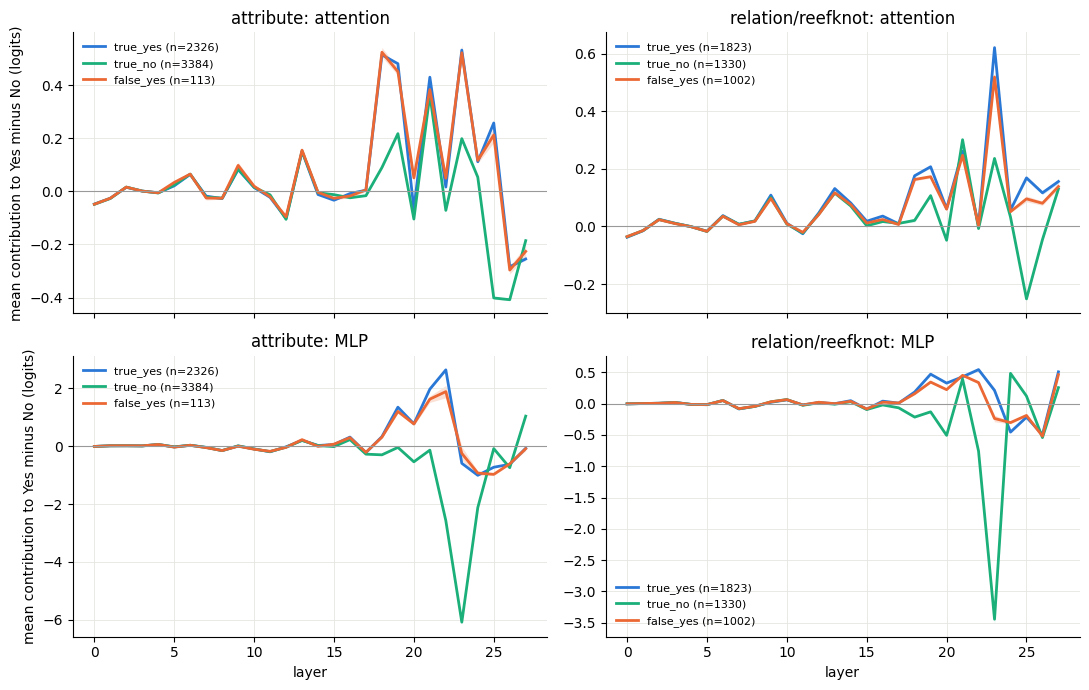

In [4]:
GROUP_COLORS = {"true_yes": "#2a78d6", "true_no": "#1baf7a", "false_yes": "#eb6834"}
UNIT_COLORS = {"attribute": "#2a78d6", "relation/reefknot": "#1baf7a", "relation/amber": "#eb6834"}
layer_axis = np.arange(N_LAYER)
attn_layer = FEATURES[:, :N_LAYER * N_HEAD].reshape(-1, N_LAYER, N_HEAD).sum(2)
mlp_layer = FEATURES[:, N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER]

fig, axes = plt.subplots(2, len(PLOT_UNITS), figsize=(5.5 * len(PLOT_UNITS), 7), sharex=True)
for col, unit in enumerate(PLOT_UNITS):
    for row, (name, arr) in enumerate([("attention", attn_layer), ("MLP", mlp_layer)]):
        ax = axes[row, col]
        for g, color in GROUP_COLORS.items():
            x = arr[df[unit_mask(unit) & df.group.eq(g)].row.to_numpy()]
            if len(x) < 2:
                continue
            m, se = x.mean(0), x.std(0, ddof=1) / np.sqrt(len(x))
            ax.plot(layer_axis, m, color=color, lw=2, label=f"{g} (n={len(x)})")
            ax.fill_between(layer_axis, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.2, lw=0)
        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{unit}: {name}")
        ax.grid(color="#e5e5e2", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
        if col == 0:
            ax.set_ylabel("mean contribution to Yes minus No (logits)")
        if row == 1:
            ax.set_xlabel("layer")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/layer_profiles.png", dpi=150)
plt.show()

In [5]:
def comp_name(i):
    if i < N_LAYER * N_HEAD:
        return f"L{i // N_HEAD} H{i % N_HEAD}"
    if i < N_LAYER * N_HEAD + N_LAYER:
        return f"L{i - N_LAYER * N_HEAD} MLP"
    return "embed"


def build_strata(unit, g_a, g_b, splits, n_bins, pair_only=True):
    sub_all = df[unit_mask(unit, pair_only) & df.group.isin([g_a, g_b]) & df.split.isin(splits)]
    strata = []
    for _, sub in sub_all.groupby("source"):
        if n_bins > 1:
            edges = np.quantile(sub.logit_diff, np.linspace(0, 1, n_bins + 1)[1:-1])
            parts = [p for _, p in sub.groupby(np.digitize(sub.logit_diff, edges))]
            min_group = MIN_BIN
        else:
            parts, min_group = [sub], MIN_GROUP
        for part in parts:
            is_a = part.group.eq(g_a).to_numpy()
            if is_a.sum() < min_group or (~is_a).sum() < min_group:
                continue
            X = FEATURES[part.row.to_numpy()].astype(np.float64)
            strata.append((X, X ** 2, is_a))
    return strata


def effects(strata, masks):
    d_sum, m_sum, w_sum = np.zeros(N_COMP), np.zeros(N_COMP), 0.0
    for (X, X2, _), mask in zip(strata, masks):
        na, nb = mask.sum(), (~mask).sum()
        mf = mask.astype(np.float64)
        sa, sa2 = mf @ X, mf @ X2
        sb, sb2 = X.sum(0) - sa, X2.sum(0) - sa2
        ma, mb = sa / na, sb / nb
        va, vb = (sa2 - na * ma ** 2) / (na - 1), (sb2 - nb * mb ** 2) / (nb - 1)
        sp = np.sqrt(np.maximum(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2), 0))
        w = na * nb / (na + nb)
        d_sum += w * (ma - mb) / np.maximum(sp, 1e-6)
        m_sum += w * (ma - mb)
        w_sum += w
    return d_sum / w_sum, m_sum / w_sum


def perm_null(strata, seed=0):
    rng = np.random.default_rng(seed)
    null = np.empty(N_PERM)
    for b in range(N_PERM):
        d, _ = effects(strata, [rng.permutation(mask) for _, _, mask in strata])
        null[b] = np.abs(d).max()
    return null

In [6]:
results = {}
for unit in UNITS:
    for cname, (g_a, g_b, n_bins) in CONTRASTS.items():
        train = build_strata(unit, g_a, g_b, ["train"], n_bins)
        held = build_strata(unit, g_a, g_b, ["val", "test"], n_bins)
        if not train or not held:
            print(f"{unit:18s} {cname:17s} not enough examples, skipped")
            continue
        d_train, m_train = effects(train, [m for _, _, m in train])
        d_held, m_held = effects(held, [m for _, _, m in held])
        null95 = float(np.quantile(perm_null(train), 0.95))
        n_a = int(sum(m.sum() for _, _, m in train))
        n_b = int(sum((~m).sum() for _, _, m in train))
        material = (
            (np.abs(d_train) > null95) & (np.sign(m_train) == np.sign(m_held)) & (np.abs(m_train) >= MIN_LOGITS)
        )
        results[(unit, cname)] = {
            "d_train": d_train, "m_train": m_train, "d_held": d_held, "m_held": m_held,
            "null95": null95, "n_a": n_a, "n_b": n_b, "material": material,
        }
        print(f"{unit:18s} {cname:17s} {g_a} {n_a}/{count_rows(unit, g_a, ['train'])} vs {g_b} {n_b} | "
              f"residual logit gap {m_train.sum():+.3f} | null95 {null95:.3f} | "
              f"significant {int((np.abs(d_train) > null95).sum())} | material {int(material.sum())}")

attribute          flip              false_yes 89/89 vs true_no 2365 | residual logit gap +16.894 | null95 0.440 | significant 244 | material 38
attribute          evidence          false_yes 89/89 vs true_yes 1624 | residual logit gap -0.886 | null95 0.439 | significant 116 | material 4
attribute          evidence_matched  false_yes 88/89 vs true_yes 1414 | residual logit gap -0.046 | null95 0.451 | significant 112 | material 2
relation/reefknot  flip              false_yes 697/697 vs true_no 927 | residual logit gap +6.335 | null95 0.199 | significant 274 | material 25
relation/reefknot  evidence          false_yes 697/697 vs true_yes 1270 | residual logit gap -1.098 | null95 0.181 | significant 385 | material 6
relation/reefknot  evidence_matched  false_yes 697/697 vs true_yes 1270 | residual logit gap -0.011 | null95 0.193 | significant 126 | material 0
relation/amber     flip              not enough examples, skipped
relation/amber     evidence          not enough examples, skippe

In [7]:
for (unit, cname), r in results.items():
    gap = r["m_train"].sum()
    top = np.argsort(-np.abs(r["m_train"]))[:K_TOP]
    print(f"--- {unit} / {cname}: {r['n_a']} vs {r['n_b']} train questions, mean logit gap {gap:+.3f} ---")
    print(f"material components: {int(r['material'].sum())} | top-{K_TOP} by logits net {r['m_train'][top].sum():+.3f} of the gap")
    table = pd.DataFrame({
        "component": [comp_name(i) for i in top[:10]],
        "depth": [f"{(i // N_HEAD if i < N_LAYER * N_HEAD else i - N_LAYER * N_HEAD if i < N_COMP - 1 else 0) / N_LAYER:.0%}" for i in top[:10]],
        "logits_train": r["m_train"][top[:10]].round(3),
        "logits_held": r["m_held"][top[:10]].round(3),
        "d_train": r["d_train"][top[:10]].round(2),
        "material": r["material"][top[:10]],
    })
    print(table.to_string(index=False))

--- attribute / flip: 89 vs 2365 train questions, mean logit gap +16.894 ---
material components: 38 | top-20 by logits net +15.523 of the gap
component depth  logits_train  logits_held  d_train  material
  L23 MLP   82%         5.863        5.739     3.26      True
  L22 MLP   79%         4.522        4.215     4.77      True
  L21 MLP   75%         1.809        1.583     4.91      True
  L20 MLP   71%         1.318        1.271     5.11      True
  L19 MLP   68%         1.245        1.234     6.12      True
  L27 MLP   96%        -1.165       -0.988    -3.38      True
  L24 MLP   86%         1.155        1.330     1.37      True
  L25 MLP   89%        -0.877       -0.929    -2.22      True
  L18 MLP   64%         0.617        0.582     3.22      True
  L23 H27   82%         0.457        0.446     4.29      True
--- attribute / evidence: 89 vs 1624 train questions, mean logit gap -0.886 ---
material components: 4 | top-20 by logits net -0.964 of the gap
component depth  logits_train  

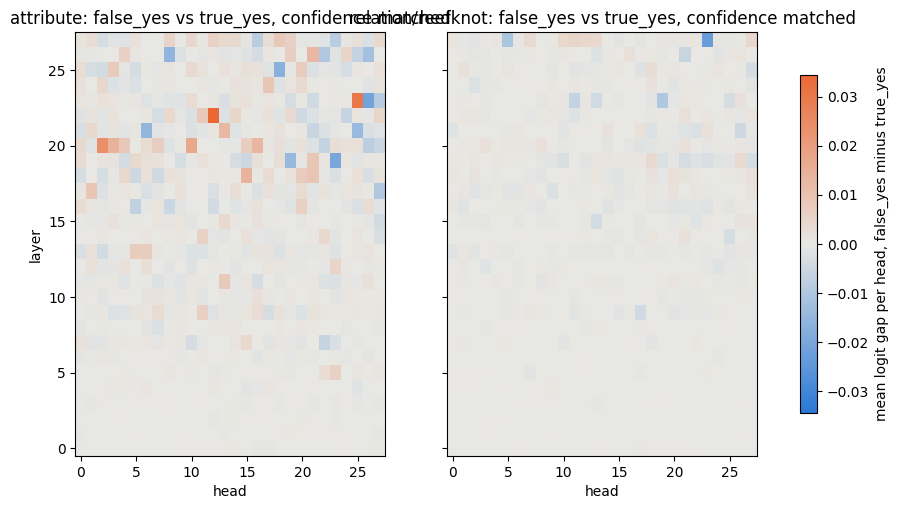

In [8]:
DIVERGING = LinearSegmentedColormap.from_list("dla_div", ["#2a78d6", "#e8e8e4", "#eb6834"])
plot_units = [u for u in PLOT_UNITS if (u, "evidence_matched") in results]
head_m = {u: results[(u, "evidence_matched")]["m_train"][:N_LAYER * N_HEAD] for u in plot_units}
limit = max(np.abs(v).max() for v in head_m.values())

fig, axes = plt.subplots(1, len(plot_units), figsize=(5.5 * len(plot_units), 5.5), sharey=True, squeeze=False)
for ax, unit in zip(axes[0], plot_units):
    im = ax.imshow(head_m[unit].reshape(N_LAYER, N_HEAD), origin="lower", cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
    ys, xs = np.nonzero(results[(unit, "evidence_matched")]["material"][:N_LAYER * N_HEAD].reshape(N_LAYER, N_HEAD))
    ax.scatter(xs, ys, s=10, color="#0b0b0b")
    ax.set_title(f"{unit}: false_yes vs true_yes, confidence matched")
    ax.set_xlabel("head")
axes[0, 0].set_ylabel("layer")
fig.colorbar(im, ax=axes.ravel().tolist(), label="mean logit gap per head, false_yes minus true_yes", shrink=0.8)
plt.savefig(f"{OUT_DIR}/head_effects_matched.png", dpi=150, bbox_inches="tight")
plt.show()

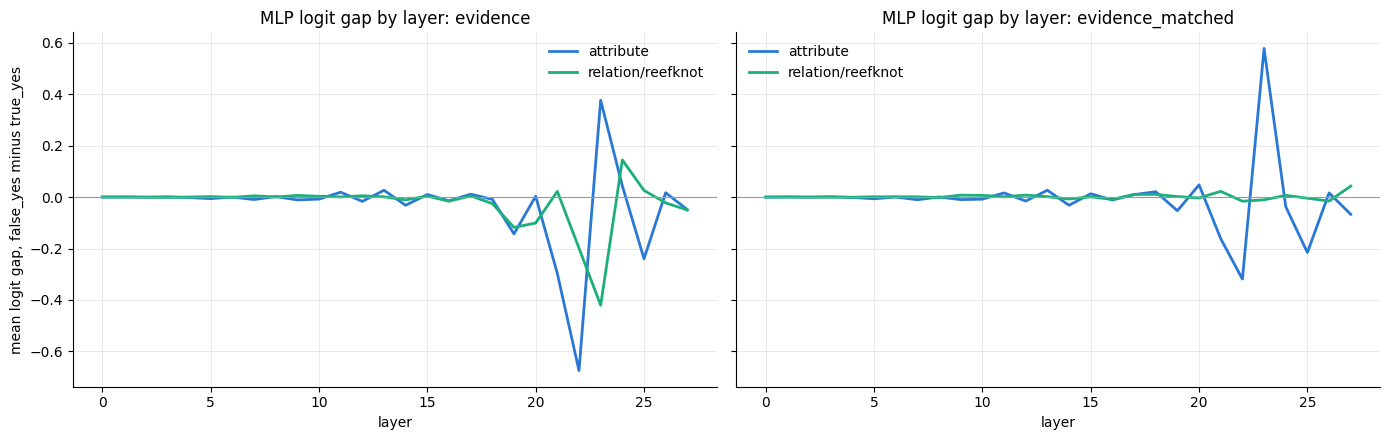

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, cname in zip(axes, ["evidence", "evidence_matched"]):
    for unit in UNITS:
        if (unit, cname) not in results:
            continue
        r = results[(unit, cname)]
        ax.plot(layer_axis, r["m_train"][N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER], color=UNIT_COLORS[unit], lw=2, label=unit)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_title(f"MLP logit gap by layer: {cname}")
    ax.set_xlabel("layer")
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
axes[0].set_ylabel("mean logit gap, false_yes minus true_yes")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mlp_effects.png", dpi=150)
plt.show()

In [10]:
COMPARE = [("attribute", "relation/reefknot"), ("attribute", "relation/amber"), ("relation/amber", "relation/reefknot")]

for cname in CONTRASTS:
    print(f"--- {cname}: top-{K_TOP} overlap by logit contribution ---")
    for a, b in COMPARE:
        if (a, cname) not in results or (b, cname) not in results:
            continue
        ma, mb = results[(a, cname)]["m_train"], results[(b, cname)]["m_train"]
        top_a, top_b = set(np.argsort(-np.abs(ma))[:K_TOP]), set(np.argsort(-np.abs(mb))[:K_TOP])
        overlap = len(top_a & top_b)
        p = hypergeom.sf(overlap - 1, N_COMP, K_TOP, K_TOP)
        print(f"{a:18s} vs {b:18s} overlap {overlap}/{K_TOP} (chance {K_TOP * K_TOP / N_COMP:.1f}, p {p:.4f}) | "
              f"spearman logits {spearmanr(ma, mb)[0]:.3f} | spearman |logits| {spearmanr(np.abs(ma), np.abs(mb))[0]:.3f} | "
              f"false_yes train {results[(a, cname)]['n_a']} / {results[(b, cname)]['n_a']}")

--- flip: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 17/20 (chance 0.5, p 0.0000) | spearman logits 0.348 | spearman |logits| 0.725 | false_yes train 89 / 697
--- evidence: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 11/20 (chance 0.5, p 0.0000) | spearman logits 0.086 | spearman |logits| 0.566 | false_yes train 89 / 697
--- evidence_matched: top-20 overlap by logit contribution ---
attribute          vs relation/reefknot  overlap 8/20 (chance 0.5, p 0.0000) | spearman logits -0.032 | spearman |logits| 0.534 | false_yes train 88 / 697


In [11]:
print("--- sensitivity: rows whose top-1 is outside the yes/no pair included, groups from the sign of the gap ---")
for (unit, cname), r in results.items():
    g_a, g_b, n_bins = CONTRASTS[cname]
    train_all = build_strata(unit, g_a, g_b, ["train"], n_bins, pair_only=False)
    if not train_all:
        continue
    _, m_all = effects(train_all, [m for _, _, m in train_all])
    n_all = int(sum(m.sum() for _, _, m in train_all))
    top_main = set(np.argsort(-np.abs(r["m_train"]))[:K_TOP])
    top_all = set(np.argsort(-np.abs(m_all))[:K_TOP])
    print(f"{unit:18s} {cname:17s} false_yes train {r['n_a']} -> {n_all} | gap {r['m_train'].sum():+.3f} -> {m_all.sum():+.3f} | "
          f"top-{K_TOP} overlap {len(top_main & top_all)}/{K_TOP} | spearman logits {spearmanr(r['m_train'], m_all)[0]:.3f}")

--- sensitivity: rows whose top-1 is outside the yes/no pair included, groups from the sign of the gap ---
attribute          flip              false_yes train 89 -> 156 | gap +16.894 -> +15.175 | top-20 overlap 19/20 | spearman logits 0.940
attribute          evidence          false_yes train 89 -> 156 | gap -0.886 -> -1.814 | top-20 overlap 15/20 | spearman logits 0.857
attribute          evidence_matched  false_yes train 88 -> 156 | gap -0.046 -> -0.094 | top-20 overlap 15/20 | spearman logits 0.850
relation/reefknot  flip              false_yes train 697 -> 722 | gap +6.335 -> +6.280 | top-20 overlap 20/20 | spearman logits 0.995
relation/reefknot  evidence          false_yes train 697 -> 722 | gap -1.098 -> -1.084 | top-20 overlap 19/20 | spearman logits 0.997
relation/reefknot  evidence_matched  false_yes train 697 -> 722 | gap -0.011 -> -0.014 | top-20 overlap 20/20 | spearman logits 0.990


In [12]:
shortlist = {}
for (unit, cname), r in results.items():
    keep = [i for i in np.argsort(-np.abs(r["m_train"])) if r["material"][i]]
    shortlist[f"{unit}/{cname}"] = [
        {"component": comp_name(i), "index": int(i), "logits_train": float(r["m_train"][i]),
         "logits_held": float(r["m_held"][i]), "d_train": float(r["d_train"][i]), "d_held": float(r["d_held"][i])}
        for i in keep[:30]
    ]
    print(f"{unit:18s} {cname:17s} shortlisted {len(shortlist[f'{unit}/{cname}'])} of {int(r['material'].sum())} material")

with open(f"{OUT_DIR}/shortlist.json", "w") as f:
    json.dump(shortlist, f)

with open(f"{OUT_DIR}/effects.json", "w") as f:
    json.dump({
        f"{unit}/{cname}": {
            "d_train": r["d_train"].tolist(), "d_held": r["d_held"].tolist(),
            "m_train": r["m_train"].tolist(), "m_held": r["m_held"].tolist(),
            "material": np.flatnonzero(r["material"]).tolist(),
            "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
        }
        for (unit, cname), r in results.items()
    }, f)

with open(f"{OUT_DIR}/analysis_meta.json", "w") as f:
    json.dump({"model": "Qwen/Qwen2.5-VL-7B-Instruct", "n_layer": N_LAYER, "n_head": N_HEAD, "n_comp": N_COMP}, f)

attribute          flip              shortlisted 30 of 38 material
attribute          evidence          shortlisted 4 of 4 material
attribute          evidence_matched  shortlisted 2 of 2 material
relation/reefknot  flip              shortlisted 25 of 25 material
relation/reefknot  evidence          shortlisted 6 of 6 material
relation/reefknot  evidence_matched  shortlisted 0 of 0 material


In [13]:
USERNAME = "nocturnalnerd18"

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "dla-qwen-analysis",
        "id": f"{USERNAME}/dla-qwen-analysis",
        "subtitle": "DLA effect sizes and shortlisted components for Qwen2.5-VL",
        "description": "Per-component effects for every attention head, MLP layer and the embedding of Qwen2.5-VL-7B on three contrasts: "
                       "flip (false_yes vs true_no), evidence (false_yes vs true_yes) and evidence_matched (false_yes vs true_yes "
                       "within bins of the model's own Yes minus No logit). Units are attribute, relation/reefknot and relation/amber. "
                       "Groups come from ground truth and the sign of the model's own gap, restricted to rows whose top-1 token is the yes/no pair. "
                       "m_* vectors are mean logit gaps and d_* vectors are Cohen's d, ranked on train and checked on val and test. "
                       "Components are indexed as layer * 28 + head for heads, 784 + layer for MLPs and 812 for the embedding. "
                       "shortlist.json holds material components: they pass a max-statistic permutation null on train, keep their sign "
                       "on held-out data and contribute at least 0.05 logits.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets create -p {OUT_DIR}

Starting upload for file head_effects_matched.png
100%|██████████████████████████████████████| 59.7k/59.7k [00:00<00:00, 96.6kB/s]
Upload successful: head_effects_matched.png (60KB)
Starting upload for file shortlist.json
100%|██████████████████████████████████████| 11.5k/11.5k [00:00<00:00, 18.3kB/s]
Upload successful: shortlist.json (12KB)
Starting upload for file analysis_meta.json
100%|██████████████████████████████████████████| 84.0/84.0 [00:00<00:00, 136B/s]
Upload successful: analysis_meta.json (84B)
Starting upload for file effects.json
100%|█████████████████████████████████████████| 427k/427k [00:00<00:00, 646kB/s]
Upload successful: effects.json (427KB)
Starting upload for file layer_profiles.png
100%|█████████████████████████████████████████| 237k/237k [00:00<00:00, 282kB/s]
Upload successful: layer_profiles.png (237KB)
Starting upload for file mlp_effects.png
100%|███████████████████████████████████████| 96.4k/96.4k [00:00<00:00, 147kB/s]
Upload successful: mlp_effects.png 